In [1]:
import numpy as np
import matplotlib.pyplot as plt
xdata = np.load("xyz_data/x_dis_N14_error_bands.npz")
ydata = np.load("xyz_data/y_dis_N14_error_bands.npz")
zdata = np.load("xyz_data/z_dis_N14_error_bands.npz")

In [2]:
tlist = xdata["tlist"]
xscar = xdata["scar"]
xqubit = xdata["qubit"]

yscar = ydata["scar"]
yqubit = ydata["qubit"]

zscar = zdata["scar"]
zqubit = zdata["qubit"]

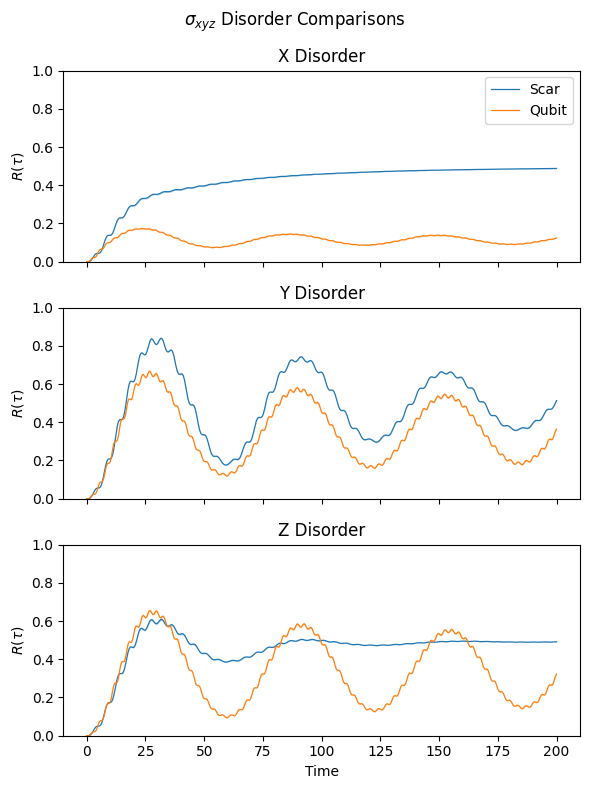

In [3]:
def band(arr):
    arr = np.atleast_2d(arr)
    m = arr.mean(0)
    sem = arr.std(0, ddof=1) / np.sqrt(arr.shape[0]) if arr.shape[0] > 1 else np.zeros_like(m)
    return m, sem

panels = [("X Disorder", xscar, xqubit),
          ("Y Disorder", yscar, yqubit),
          ("Z Disorder", zscar, zqubit)]

fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)
fig.suptitle(r"$\sigma_{xyz}$ Disorder Comparisons")

for ax, (title, s, q) in zip(axs, panels):
    for arr, lab in [(s, "Scar"), (q, "Qubit")]:
        m, sem = band(arr)
        line, = ax.plot(tlist, m, lw=0.9, label=lab)
        ax.fill_between(tlist, m - sem, m + sem,
                        color=line.get_color(), alpha=0.3, lw=0)
    ax.set_title(title)
    ax.set_ylabel(r"$R(\tau)$")
    ax.set_ylim(0, 1)

axs[0].legend()
axs[2].set_xlabel("Time")

plt.tight_layout()
plt.savefig(f"figures/xyz_N{14}_dis{0.3}_reals{500}.pdf")
plt.show()